# Example DAGrunner usage

Let's demonstrate defining a callable object which represents some user processing step we wish to execute, along with a minimal NetworkX graph which describes a network of processing steps and their relationship to one another.  Our example will demonstrate the following:

- Defining a callable object to be executed for a given node in our graph.
  - Passing data in memory (our function returns the result).
- Defining a minimal NetworkX graph.
  - Defining an example node identity for our NetworkX graph.
- Execution of our graph with our chosen scheduler.

The currency of DAGrunner is the [networkx.DiGraph](https://networkx.org/documentation/stable/reference/classes/digraph.html) object.  DAGrunner is provided this NetworkX graph object (or python dot path to one) and told to execute it with a specified scheduler.  A layer of abstraction is provided to support a range of schedulers.
The question becomes, "how does DAGrunner know how to execute my NetworkX graph?"

By default, DAGrunner pre-defines a default [plugin-executor](https://github.com/MetOffice/dagrunner/blob/main/docs/dagrunner.execute_graph.md#function-plugin_executor) function which is likely sufficient for most, out of the box.  This functions wraps each node in your graph and characterises how a node in your graph is executed by the underlying scheduler and what it needs to understand how to be executed.  We will go into this in some detail later.

## Pre-requisites

Ensure that 'dagrunner' is on the `PYTHONPATH` (i.e. [installation](../README.md#installation)).
For the purpose of this notebook, we will assume to manually add DAGrunner to the path...

In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

## Defining a processing step (AKA something to execute, some callable)

First, let's define some callable that represents some processing step (`add`).
The callable will typically do something to manipulate the data provided before returning this as a result, ready for descendant nodes to further process this data.
The positional argument will represent the return values from by direct ancestor nodes passed to the one being executed.
By our callable returning an object, we are passing data in memory along the node tree.

Additionally, we will demonstrate passing in a keyword argument and we will configure this differently for different nodes to be executed.

In [39]:
def add(*arg, const=0):
    return sum(arg) + const

## NetworkX graph definition

A networkx graph is constructed from a list of edges (see official [edge](https://networkx.org/documentation/stable/reference/glossary.html#term-edge) definition) and/or nodes (see official [node](https://networkx.org/documentation/stable/reference/glossary.html#term-node) definition).  We highly recommend a general reading of the official documentation around the topic, but in short, graphs nodes represents unique application call identities and the edges represent the relationship/connectivity between these identities (nodes) in our graph.

Often we additionally use the term 'settings'.  This term is typically used to mean a dictionary object which maps node identities and its attributes (see the official [node attributes](https://networkx.org/documentation/stable/reference/glossary.html#term-node-attribute) definition).  It's these node attributes that inform DAGRunnder via it's internal [plugin-executor](https://github.com/MetOffice/dagrunner/blob/main/docs/dagrunner.execute_graph.md#function-plugin_executor) on how to execute a given node.  We will go through this in our example.

### Define a 'node' identiy for our NetworkX graph

We are free to define our node (graph identities) in any way we choose.  However, we highly recommend the use of immutable containers such as [dataclasses](https://docs.python.org/3/library/dataclasses.html#dataclasses.dataclass) or [namedtuples](https://docs.python.org/3/library/collections.html#collections.namedtuple) as these are highly effective means for representing flexible immutable objects.

For simplicity, we note that strings are also immutable so we will stick with that for now.

In [40]:
node0 = "a"
node1 = "b"
node2 = "c"
node3 = "d"

### Define a networkx graph

Here, we will demonstrate defining a primitive graph where a single node leads to two independent branches of execution.

Note: The networkx graph is most often referred to as the 'configuration' or 'recipe', when discussed within the scope of an orchestration engine.  This is important as 'graph' as well as these other terms are rather ambiguous and dependent on the context and layer we are referring.

In [41]:
EDGES = [
    [node0, node1],
    [node1, node3],
    [node0, node2],
    [node2, node3],
]

SETTINGS = {
    node0: {
        "call": (lambda: 0,),
    },
    node1: {
        "call": (add, {"const": 1}),
    },
    node2: {
        "call": (add, {"const": 3}),
    },
    node3: {
        "call": (add, {"const": 10}),
    },
}

Let's look at what we have just defined.  Some edges and some settings*

*reminder that by settings, we mean a `{node, attributes}` lookup.

In [42]:
from pprint import pprint

print("edges:")
pprint(EDGES)
print("\nsettings:")
pprint(SETTINGS)

edges:
[['a', 'b'], ['b', 'd'], ['a', 'c'], ['c', 'd']]

settings:
{'a': {'call': (<function <lambda> at 0x7f9fd7b85580>,)},
 'b': {'call': (<function add at 0x7f9fd7b851c0>, {'const': 1})},
 'c': {'call': (<function add at 0x7f9fd7b851c0>, {'const': 3})},
 'd': {'call': (<function add at 0x7f9fd7b851c0>, {'const': 10})}}


We see that the data (attributes) for each node define what and how DAGrunner will execute that node, our 'call', specifically from the nodes attributes dictionary.
It's value takes the form `(callable, callable_keyword_arguments)`.
This 'callable' is what represents the object to be executed or python module dot path to it.  As mentioned previously, see [plugin-executor](https://github.com/MetOffice/dagrunner/blob/main/docs/dagrunner.execute_graph.md#function-plugin_executor) for further details on how this works.

## Execute our graph

To execute our graph, we will make use of the built-in [ExecuteGraph](docs/dagrunner.execute_graph.md#class-executegraph) class.
This class accepts our [networkx.DiGraph](https://networkx.org/documentation/stable/reference/classes/digraph.html) object as input.  It can also optionally take a tuple `(edges, nodes)`, which in turn DAGrunner will turn into a [networkx.DiGraph](https://networkx.org/documentation/stable/reference/classes/digraph.html) for us.  We typically recommend that users pass DAGrunner a NetworkX graph they have constructed themselves, but for simplicity, we will stick to providing it with our edges and nodes.

Furthermore, we will specify the 'single-threaded' scheduler to begin with.  This is the dask serial execution scheduler.

In [44]:
from importlib import reload

import dagrunner.execute_graph
from dagrunner.execute_graph import ExecuteGraph

reload(dagrunner.execute_graph)

graph = ExecuteGraph((EDGES, SETTINGS), scheduler="single-threaded", verbose=True)

### Graph visualisation

We provide some out-of-the-box capability to easily visualise networkx graphs (using the javascript mermaid library).

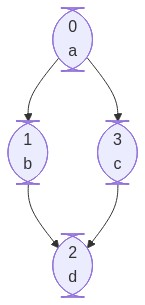

In [45]:
graph.visualise()

We can clearly see the two distinct branches of execution, leading to a common step dependent on two nodes.

### Execution

Now, let's execute this graph and seeing how things progress through the execution (we specified `verbose=True` above).

In [46]:
graph()

args: []
call: (<function <lambda> at 0x7f9fd7b85580>,)
<lambda>(*[], **{})
result: 0
args: [0]
call: (<function add at 0x7f9fd7b851c0>, {'const': 3})
add(*[0], **{'const': 3})
result: 3
args: [0]
call: (<function add at 0x7f9fd7b851c0>, {'const': 1})
add(*[0], **{'const': 1})
result: 1
args: [1, 3]
call: (<function add at 0x7f9fd7b851c0>, {'const': 10})
add(*[1, 3], **{'const': 10})
result: 14
Elapsed time: 0.01s


We can see from the stdout: 'args' representing input arguments to our particular node; 'call', the attribute representing how to execute this node and 'result', state has been passed along the execution pipeline and additions made in the way we expect.

# Using DAGrunner via the commandline

Using DAGrunner as part of real world scenarios will likely require interfacing to it externally.  This can be done via the commandline.

DAGrunner provides the `dagrunner-execute-graph` script for this purpose.

This script provides a CLI that maps 1-to-1 with the UI of [ExecuteGraph](docs/dagrunner.execute_graph.md#class-executegraph), so everything described above can be repeated via the commandline via this script.

The only difference when calling via this script, is that clearly our networkx graph (or callable that returns one), must be provided via a string representing a Python dot path to this object, rather than the object itself.  DAGrunner will then module load this object accordingly.

# Example DAGrunner usage: real-world example

# Customisation

## Customised graph construction

"What if I require some degree of control over how the graph is constructed based on how its called?"

The [ExecuteGraph](docs/dagrunner.execute_graph.md#class-executegraph) class can also be provided a **callable object** which returns a networkx graph.  As mentioned previously, similarly, this can be a python dot module path to such a callable object too.  When providing a callable that returns a networkx graph, rather than the networkx graph directly, you may want to such a callable to accept parameters too.  This is a means for context dependent graph construction as well as lazy graph construction.  Parameters to our callable are provided to [ExecuteGraph](docs/dagrunner.execute_graph.md#class-executegraph) via the `networkx_graph_kwargs` parameter.

This offers huge amounts of flexibility and importantly ensures that a separation of concerns is maintained.  That is, that DAGrunner only concerns itself with providing a framework by which to execute networkx graphs, rather than taking responsibility to define such a graph.

Typical usecases include:
- Lazy graph construction.
  - Being a callable means we benefit from lazy construction, where the graph callable to construct your graph isn't itself called until execution of the graph.
- Context dependent graph construction.
  - Cycle dependent graph construction.
  - ...

Here is an example, where we might request a networkx graph which is constructed which is dependent on the particular cycle to which we are executing:

```python
def gen_networkx(cycle):
    graph = graph_gen(cycle)
    return graph
```

This calls a fictitious `graph_gen`.  Representing something you have defined that returns your cycle dependent networkx graph construction.

We can then instantiate our `ExecuteGraph` object accordingly with this graph construction callable object and pass any parameters it should take (like the cycle in this case):

```python
graph = ExecuteGraph(gen_networkx, networkx_graph_kwargs={"cycle": dummy_cycle})
```

We can see how we might achieve great amount of flexibility through such an approach, allowing us to meet project specific needs.

## Customised node execution

We mentioned previously how DAGrunner [ExecuteGraph](docs/dagrunner.execute_graph.md#class-executegraph) class by default utilises its built-in [plugin-executor](https://github.com/MetOffice/dagrunner/blob/main/docs/dagrunner.execute_graph.md#function-plugin_executor) function to execute each node that it wraps in our networkx graph.

It is this function that defines what we expect to find defined for our graphs node attributes.  Defining the need for this 'call' attribute in particular which tells it what callable object to call, along with any arguments to pass to it.  This callable object can be the object itself, or otherwise again a python doc path to this object.

We can of course define our own 'plugin executor' and pass this on initialisation of our [ExecuteGraph](docs/dagrunner.execute_graph.md#class-executegraph) class.

However, this should not normally be needed.  We provide an illustrated example here for completeness.  In our example, we will extend the built-in executor rather than replace it:

In [8]:
from dagrunner.execute_graph import ExecuteGraph, plugin_executor


def custom_plugin_executor(*args, call=None, verbose=False, dry_run=False, **kwargs):
    # do something custom
    return plugin_executor(*args, call=call, verbose=verbose, dry_run=dry_run, **kwargs)

Now we can utilise our project specific plugin executor by initialising our [ExecuteGraph](docs/dagrunner.execute_graph.md#class-executegraph) class with this object.

```python
ExecuteGraph(..., plugin_executor=custom_plugin_executor, ...)
```

## Further customisation

Note that you may choose to subclass [ExecuteGraph](docs/dagrunner.execute_graph.md#class-executegraph) and or write a custom commandline script to call it, depending on your requirements.

As with the case of a custom `plugin_executor``, it's unlikely that you will find such a need for customisation such as this.